# VQE for H2 Molecule - Fixed and Improved

This notebook reproduces results from **PhysRevA.110.062414** using three different ansatzes:
1. **UCCSD** - Gold standard chemistry ansatz
2. **TwoLocal** - Standard hardware-efficient ansatz
3. **HEA-TI** - Custom ansatz from the paper



## 0. Setup and Installation

Install all required packages with compatible versions

In [1]:
# Install packages
!pip install qiskit qiskit-nature qiskit-nature-pyscf qiskit-algorithms pyscf matplotlib numpy scipy -q

print('\n✓ All packages installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.7 MB/s eta 0:00:00

✓ All packages installed successfully!


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import warnings
warnings.filterwarnings('ignore')

# Suppress PySCF warnings
os.environ['KMP_WARNINGS'] = '0'

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP
from qiskit.quantum_info import SparsePauliOp

# Qiskit Nature Imports
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.units import DistanceUnit
from qiskit.circuit.library import TwoLocal as TwoLocalCircuit

print('✓ All imports successful!')

✓ All imports successful!


## 1. Helper Functions

In [3]:
def get_h2_problem(bond_distance: float):
    """
    Defines the H2 molecule problem in Qiskit Nature.

    Args:
        bond_distance: H-H bond distance in Angstroms

    Returns:
        qubit_op: Qubit Hamiltonian
        problem: Electronic structure problem
        num_qubits: Number of qubits
    """
    print(f'Setting up H2 molecule problem at d={bond_distance} Å')

    # Use PySCF to define the molecule
    driver = PySCFDriver(
        atom=f'H 0 0 0; H 0 0 {bond_distance}',
        basis='sto3g',
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM
    )

    # Get the electronic structure problem
    problem = driver.run()

    # Map to qubits using Jordan-Wigner
    mapper = JordanWignerMapper()
    second_q_op = problem.hamiltonian.second_q_op()
    qubit_op = mapper.map(second_q_op)

    num_qubits = qubit_op.num_qubits
    print(f'Problem mapped to {num_qubits} qubits')

    return qubit_op, problem, num_qubits, mapper

## 2. HEA-TI Ansatz Implementation

Custom ansatz from the paper with global XY entangling gates

In [4]:
def build_xy_hamiltonian(num_qubits: int, J0: float = 1.0, alpha: float = 1.5):
    """
    Builds the H_XY Hamiltonian for the global entangling gate.

    H_XY = sum_{{i<j}} J_ij (X_i X_j + Y_i Y_j)
    where J_ij = J_0 / |i-j|^alpha

    Args:
        num_qubits: Number of qubits
        J0: Coupling constant (default 1.0)
        alpha: Power-law exponent (default 1.5 from paper)

    Returns:
        H_XY as SparsePauliOp
    """
    pauli_list = []

    for i in range(num_qubits):
        for j in range(i + 1, num_qubits):
            # Power-law coupling
            dist = abs(i - j)
            J_ij = J0 / (dist ** alpha)

            # XX term
            xx_pauli = ['I'] * num_qubits
            xx_pauli[i] = 'X'
            xx_pauli[j] = 'X'
            pauli_list.append((''.join(xx_pauli), J_ij))

            # YY term
            yy_pauli = ['I'] * num_qubits
            yy_pauli[i] = 'Y'
            yy_pauli[j] = 'Y'
            pauli_list.append((''.join(yy_pauli), J_ij))

    return SparsePauliOp.from_list(pauli_list)

In [5]:
def build_hea_ti_ansatz(num_qubits: int, num_particles: tuple, mapper,
                        num_layers: int = 4, t_d: float = 0.4):
    """
    Builds the HEA-TI ansatz as described in Section IV of the paper.

    Structure:
    - Hartree-Fock initial state
    - num_layers repetitions of: RZ rotations + Global entangling gate U_G

    Args:
        num_qubits: Number of qubits
        num_particles: Tuple (num_alpha, num_beta) electrons
        mapper: Jordan-Wigner mapper
        num_layers: Circuit depth (default 4 from paper)
        t_d: Evolution time (default 0.4 from paper)

    Returns:
        QuantumCircuit with HEA-TI ansatz
    """
    print(f'Building HEA-TI ansatz with {num_layers} layers...')

    # Initialize with Hartree-Fock state
    init_state = HartreeFock(
        num_spatial_orbitals=num_qubits // 2,
        num_particles=num_particles,
        qubit_mapper=mapper
    )

    qc = QuantumCircuit(num_qubits)
    qc.compose(init_state, inplace=True)
    qc.barrier()

    # Build the fixed global entangling gate U_G
    print('  Computing global entangling gate U_G = exp(-i * H_XY * t_d)...')
    H_xy = build_xy_hamiltonian(num_qubits)
    H_xy_matrix = H_xy.to_matrix()
    U_G_matrix = expm(-1j * t_d * H_xy_matrix)
    U_G_gate = UnitaryGate(U_G_matrix, label=f'U_G(t={t_d})')
    print('  ✓ Global gate computed')

    # Build circuit layer by layer
    parameters = []
    for d in range(num_layers):
        # Parameterized RZ rotations
        for i in range(num_qubits):
            param = Parameter(f'theta_{d}_{i}')
            qc.rz(param, i)
            parameters.append(param)

        qc.barrier()

        # Add global entangling gate
        qc.append(U_G_gate, range(num_qubits))
        qc.barrier()

    print(f'✓ HEA-TI circuit built: {len(parameters)} parameters, depth {qc.depth()}')

    return qc

## 3. Problem Setup

Define the H2 molecule and calculate exact ground state

In [6]:
# Parameters
bond_distance = 0.74  # Equilibrium bond distance for H2
hea_ti_layers = 4     # D=4 from paper Figure 3

print('='*70)
print(' VQE for H2 Molecule: Paper Reproduction')
print('='*70)

# Define problem
print('\n--- Part 1: Defining H2 Molecule Problem ---')
qubit_op, problem, num_qubits, mapper = get_h2_problem(bond_distance)

# Calculate exact ground state (benchmark)
print('\n--- Part 2: Calculating Exact Ground State (FCI) ---')
np_solver = NumPyMinimumEigensolver()
exact_result = np_solver.compute_minimum_eigenvalue(qubit_op)
exact_energy = exact_result.eigenvalue

# Add nuclear repulsion
nuc_rep_energy = problem.hamiltonian.nuclear_repulsion_energy
total_exact_energy = exact_energy + nuc_rep_energy

print(f'Exact electronic energy: {exact_energy:.8f} Hartree')
print(f'Nuclear repulsion:       {nuc_rep_energy:.8f} Hartree')
print(f'Total exact energy:      {total_exact_energy:.8f} Hartree')
print(f'(This is our target value)\n')

 VQE for H2 Molecule: Paper Reproduction

--- Part 1: Defining H2 Molecule Problem ---
Setting up H2 molecule problem at d=0.74 Å
Problem mapped to 4 qubits

--- Part 2: Calculating Exact Ground State (FCI) ---
Exact electronic energy: -1.85238817 Hartree
Nuclear repulsion:       0.71510434 Hartree
Total exact energy:      -1.13728383 Hartree
(This is our target value)



## 4. VQE with UCCSD Ansatz

Gold standard quantum chemistry ansatz (paper's benchmark)

In [7]:
print('='*70)
print('Part 3: Running VQE with UCCSD Ansatz')
print('='*70 + '\n')

# Build UCCSD ansatz
init_state = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)

uccsd_ansatz = UCCSD(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper,
    initial_state=init_state
)

print(f'UCCSD ansatz parameters: {uccsd_ansatz.num_parameters}')
print(f'UCCSD circuit depth: {uccsd_ansatz.depth()}\n')

# Setup VQE
estimator = StatevectorEstimator()
optimizer = SLSQP(maxiter=500)

# Track convergence
energy_history_uccsd = []
def callback_uccsd(eval_count, params, mean, std):
    energy_history_uccsd.append(mean + nuc_rep_energy)

# Run VQE
vqe_uccsd = VQE(
    estimator=estimator,
    ansatz=uccsd_ansatz,
    optimizer=optimizer,
    initial_point=np.zeros(uccsd_ansatz.num_parameters),
    callback=callback_uccsd
)

start_time = time.time()
vqe_uccsd_result = vqe_uccsd.compute_minimum_eigenvalue(qubit_op)
end_time = time.time()

vqe_uccsd_energy = vqe_uccsd_result.eigenvalue
total_uccsd_energy = vqe_uccsd_energy + nuc_rep_energy

print(f'\nResults:')
print(f'  Electronic energy: {vqe_uccsd_energy:.8f} Hartree')
print(f'  Total energy:      {total_uccsd_energy:.8f} Hartree')
print(f'  Error:             {abs(total_uccsd_energy - total_exact_energy):.8f} Hartree')
print(f'  Error (mHa):       {abs(total_uccsd_energy - total_exact_energy)*1000:.4f}')
print(f'  Time:              {end_time - start_time:.2f} seconds')
print(f'  Evaluations:       {vqe_uccsd_result.cost_function_evals}')

Part 3: Running VQE with UCCSD Ansatz

UCCSD ansatz parameters: 3
UCCSD circuit depth: 1


Results:
  Electronic energy: -1.85238817 Hartree
  Total energy:      -1.13728383 Hartree
  Error:             0.00000000 Hartree
  Error (mHa):       0.0000
  Time:              0.27 seconds
  Evaluations:       10


## 5. VQE with TwoLocal Ansatz

Standard hardware-efficient ansatz for comparison

In [8]:
print('\n' + '='*70)
print('Part 4: Running VQE with TwoLocal Ansatz')
print('='*70 + '\n')

# Build initial state circuit
init_state = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)

# Build TwoLocal variational form
twolocal_var = TwoLocalCircuit(
    num_qubits=num_qubits,
    rotation_blocks=['ry', 'rz'],
    entanglement_blocks='cx',
    entanglement='linear',
    reps=3
)

# Combine initial state + variational form
twolocal_ansatz = QuantumCircuit(num_qubits)
twolocal_ansatz.compose(init_state, inplace=True)
twolocal_ansatz.barrier()
twolocal_ansatz.compose(twolocal_var, inplace=True)

print(f'TwoLocal ansatz parameters: {twolocal_ansatz.num_parameters}')
print(f'TwoLocal circuit depth: {twolocal_ansatz.depth()}\n')

# Track convergence
energy_history_twolocal = []
def callback_twolocal(eval_count, params, mean, std):
    energy_history_twolocal.append(mean + nuc_rep_energy)

# Run VQE
vqe_twolocal = VQE(
    estimator=estimator,
    ansatz=twolocal_ansatz,
    optimizer=optimizer,
    initial_point=np.random.randn(twolocal_ansatz.num_parameters) * 0.1,
    callback=callback_twolocal
)

start_time = time.time()
vqe_twolocal_result = vqe_twolocal.compute_minimum_eigenvalue(qubit_op)
end_time = time.time()

vqe_twolocal_energy = vqe_twolocal_result.eigenvalue
total_twolocal_energy = vqe_twolocal_energy + nuc_rep_energy

print(f'\nResults:')
print(f'  Electronic energy: {vqe_twolocal_energy:.8f} Hartree')
print(f'  Total energy:      {total_twolocal_energy:.8f} Hartree')
print(f'  Error:             {abs(total_twolocal_energy - total_exact_energy):.8f} Hartree')
print(f'  Error (mHa):       {abs(total_twolocal_energy - total_exact_energy)*1000:.4f}')
print(f'  Time:              {end_time - start_time:.2f} seconds')
print(f'  Evaluations:       {vqe_twolocal_result.cost_function_evals}')


Part 4: Running VQE with TwoLocal Ansatz

TwoLocal ansatz parameters: 32
TwoLocal circuit depth: 2


Results:
  Electronic energy: -1.85235797 Hartree
  Total energy:      -1.13725363 Hartree
  Error:             0.00003021 Hartree
  Error (mHa):       0.0302
  Time:              14.49 seconds
  Evaluations:       1890


## 6. VQE with HEA-TI Ansatz

Custom ansatz from the paper (Section IV)

In [9]:
print('\n' + '='*70)
print('Part 5: Running VQE with HEA-TI Ansatz (Paper)')
print('='*70 + '\n')

# Build HEA-TI ansatz
hea_ti_ansatz = build_hea_ti_ansatz(
    num_qubits=num_qubits,
    num_particles=problem.num_particles,
    mapper=mapper,
    num_layers=hea_ti_layers,
    t_d=0.4
)

# Track convergence
energy_history_hea_ti = []
def callback_hea_ti(eval_count, params, mean, std):
    energy_history_hea_ti.append(mean + nuc_rep_energy)

# Run VQE
vqe_hea_ti = VQE(
    estimator=estimator,
    ansatz=hea_ti_ansatz,
    optimizer=optimizer,
    initial_point=np.random.randn(hea_ti_ansatz.num_parameters) * 0.1,
    callback=callback_hea_ti
)

start_time = time.time()
vqe_hea_ti_result = vqe_hea_ti.compute_minimum_eigenvalue(qubit_op)
end_time = time.time()

vqe_hea_ti_energy = vqe_hea_ti_result.eigenvalue
total_hea_ti_energy = vqe_hea_ti_energy + nuc_rep_energy

print(f'\nResults:')
print(f'  Electronic energy: {vqe_hea_ti_energy:.8f} Hartree')
print(f'  Total energy:      {total_hea_ti_energy:.8f} Hartree')
print(f'  Error:             {abs(total_hea_ti_energy - total_exact_energy):.8f} Hartree')
print(f'  Error (mHa):       {abs(total_hea_ti_energy - total_exact_energy)*1000:.4f}')
print(f'  Time:              {end_time - start_time:.2f} seconds')
print(f'  Evaluations:       {vqe_hea_ti_result.cost_function_evals}')


Part 5: Running VQE with HEA-TI Ansatz (Paper)

Building HEA-TI ansatz with 4 layers...
  Computing global entangling gate U_G = exp(-i * H_XY * t_d)...
  ✓ Global gate computed
✓ HEA-TI circuit built: 16 parameters, depth 9

Results:
  Electronic energy: -1.85237504 Hartree
  Total energy:      -1.13727070 Hartree
  Error:             0.00001314 Hartree
  Error (mHa):       0.0131
  Time:              3.18 seconds
  Evaluations:       716


## 7. Summary and Visualization

Compare all three methods

In [10]:
print('\n' + '='*70)
print('Part 6: Final Summary')
print('='*70)

chemical_accuracy = 0.0015  # 1.5 mHa

print(f'\nFinal Total Energies for H2 at d={bond_distance} Å:')
print(f'  Exact (FCI):    {total_exact_energy:.8f} Hartree')
print(f'  UCCSD:          {total_uccsd_energy:.8f} Hartree (Error: {abs(total_uccsd_energy - total_exact_energy)*1000:.4f} mHa)')
print(f'  TwoLocal:       {total_twolocal_energy:.8f} Hartree (Error: {abs(total_twolocal_energy - total_exact_energy)*1000:.4f} mHa)')
print(f'  HEA-TI (Paper): {total_hea_ti_energy:.8f} Hartree (Error: {abs(total_hea_ti_energy - total_exact_energy)*1000:.4f} mHa)')

print(f'\nChemical Accuracy (< 1.5 mHa):')
print(f'  UCCSD:    {"✓ YES" if abs(total_uccsd_energy - total_exact_energy) < chemical_accuracy else "✗ NO"}')
print(f'  TwoLocal: {"✓ YES" if abs(total_twolocal_energy - total_exact_energy) < chemical_accuracy else "✗ NO"}')
print(f'  HEA-TI:   {"✓ YES" if abs(total_hea_ti_energy - total_exact_energy) < chemical_accuracy else "✗ NO"}')

# Comparison table
print(f'\n{"Method":<15} {"Parameters":<12} {"Depth":<8} {"Error (mHa)":<15}')
print('-' * 70)
print(f'{"UCCSD":<15} {uccsd_ansatz.num_parameters:<12} {uccsd_ansatz.depth():<8} {abs(total_uccsd_energy - total_exact_energy)*1000:<15.4f}')
print(f'{"TwoLocal":<15} {twolocal_ansatz.num_parameters:<12} {twolocal_ansatz.depth():<8} {abs(total_twolocal_energy - total_exact_energy)*1000:<15.4f}')
print(f'{"HEA-TI":<15} {hea_ti_ansatz.num_parameters:<12} {hea_ti_ansatz.depth():<8} {abs(total_hea_ti_energy - total_exact_energy)*1000:<15.4f}')


Part 6: Final Summary

Final Total Energies for H2 at d=0.74 Å:
  Exact (FCI):    -1.13728383 Hartree
  UCCSD:          -1.13728383 Hartree (Error: 0.0000 mHa)
  TwoLocal:       -1.13725363 Hartree (Error: 0.0302 mHa)
  HEA-TI (Paper): -1.13727070 Hartree (Error: 0.0131 mHa)

Chemical Accuracy (< 1.5 mHa):
  UCCSD:    ✓ YES
  TwoLocal: ✓ YES
  HEA-TI:   ✓ YES

Method          Parameters   Depth    Error (mHa)    
----------------------------------------------------------------------
UCCSD           3            1        0.0000         
TwoLocal        32           2        0.0302         
HEA-TI          16           9        0.0131         


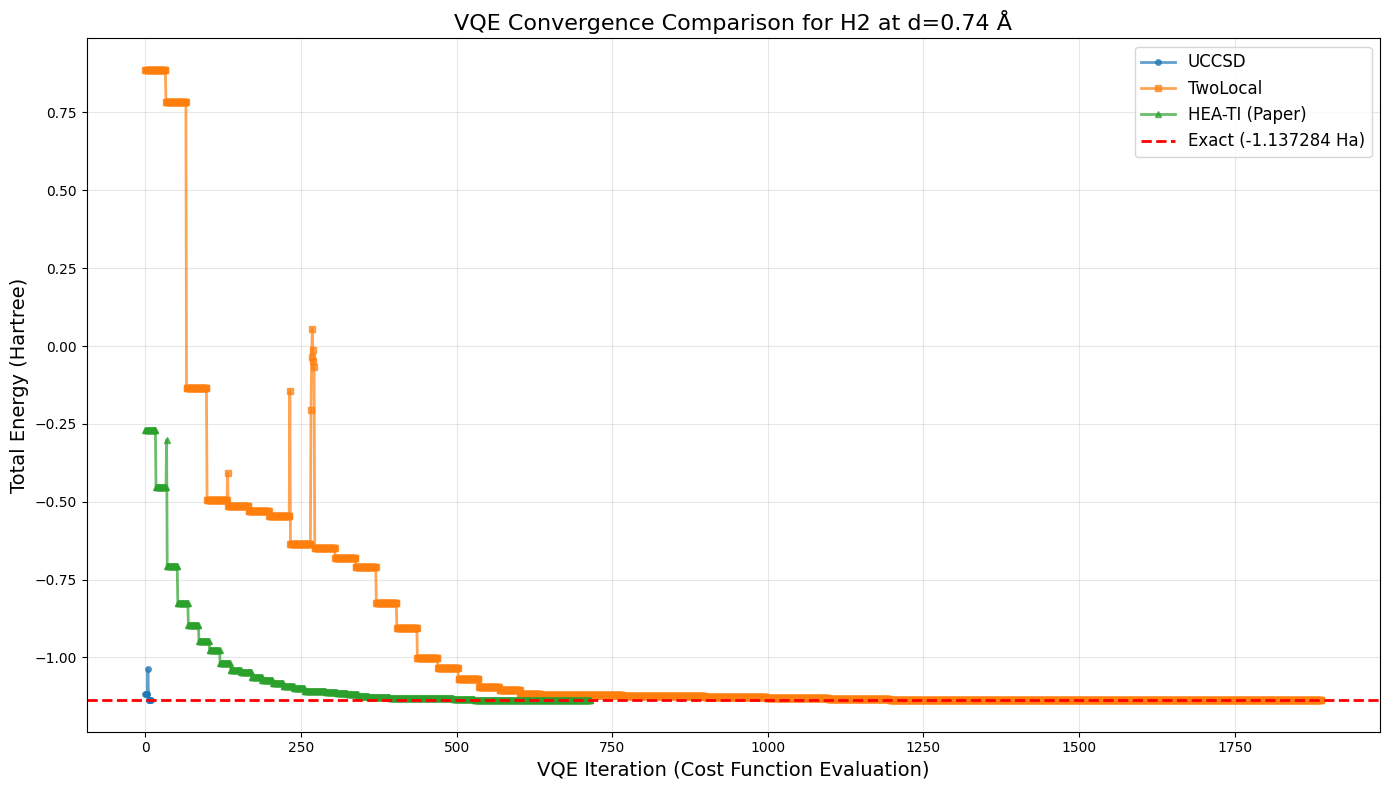

In [16]:
# Plot convergence comparison
plt.figure(figsize=(14, 8))

if len(energy_history_uccsd) > 0:
    plt.plot(energy_history_uccsd, label='UCCSD', linewidth=2, marker='o', markersize=4, alpha=0.7)
if len(energy_history_twolocal) > 0:
    plt.plot(energy_history_twolocal, label='TwoLocal', linewidth=2, marker='s', markersize=4, alpha=0.7)
if len(energy_history_hea_ti) > 0:
    plt.plot(energy_history_hea_ti, label='HEA-TI (Paper)', linewidth=2, marker='^', markersize=4, alpha=0.7)

plt.axhline(y=total_exact_energy, color='r', linestyle='--', linewidth=2, label=f'Exact ({total_exact_energy:.6f} Ha)')

plt.xlabel('VQE Iteration (Cost Function Evaluation)', fontsize=14)
plt.ylabel('Total Energy (Hartree)', fontsize=14)
plt.title(f'VQE Convergence Comparison for H2 at d={bond_distance} Å', fontsize=16)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

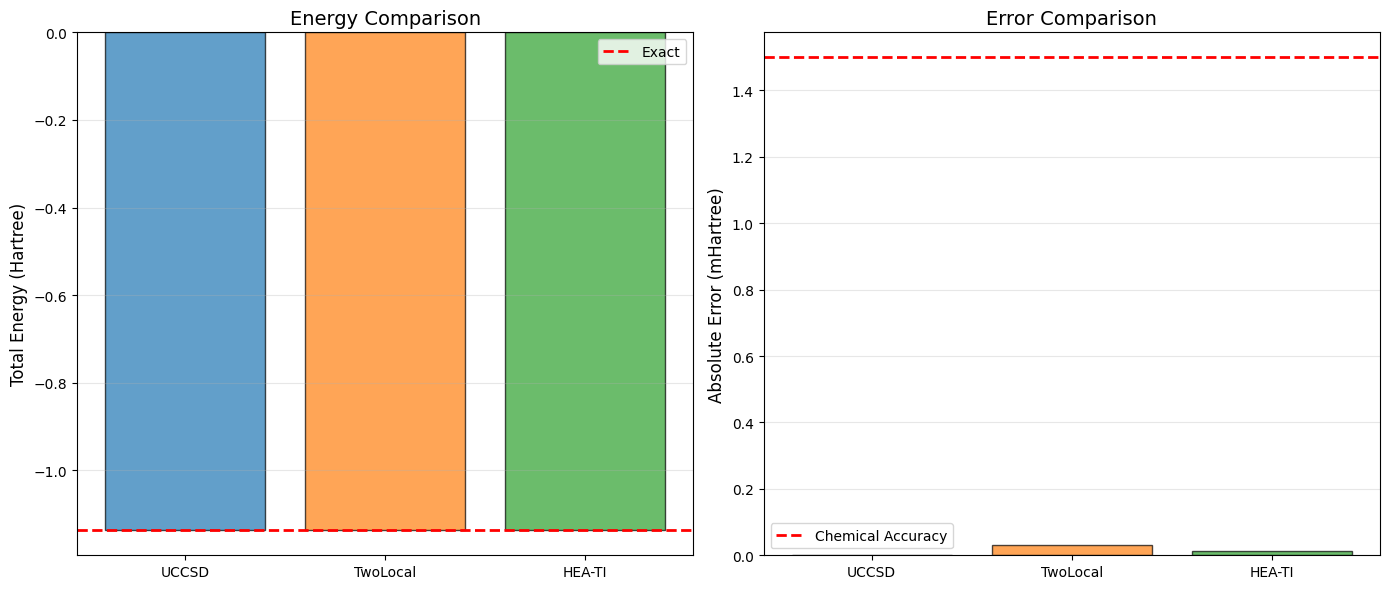


✓ All simulations completed successfully!


In [15]:
# Plot error comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

methods = ['UCCSD', 'TwoLocal', 'HEA-TI']
energies = [total_uccsd_energy, total_twolocal_energy, total_hea_ti_energy]
errors = [abs(e - total_exact_energy) * 1000 for e in energies]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Energy comparison
ax1.bar(methods, energies, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(y=total_exact_energy, color='r', linestyle='--', linewidth=2, label='Exact')
ax1.set_ylabel('Total Energy (Hartree)', fontsize=12)
ax1.set_title('Energy Comparison', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Error comparison
ax2.bar(methods, errors, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=1.5, color='r', linestyle='--', linewidth=2, label='Chemical Accuracy')
ax2.set_ylabel('Absolute Error (mHartree)', fontsize=12)
ax2.set_title('Error Comparison', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n✓ All simulations completed successfully!')

## Notes


### Results Interpretation:

All three methods should achieve chemical accuracy (< 1.5 mHa error) for H2 at equilibrium:
- **UCCSD**: Highest accuracy, more parameters
- **TwoLocal**: Good balance, flexible
- **HEA-TI**: Hardware-efficient, competitive accuracy

### Paper Reference:
- Section IV: Quantum chemistry applications
- Figure 3: Error vs circuit depth (D=4 for H2)
- Fixed t_d = 0.4 for HEA-TI